# Semantic Profile 기반 중소기업 매칭 시스템 Baseline (Faiss)
본 노트북은 `user_data.csv`와 `company_jobdescription.csv`를 활용하여 다음과 같은 작업을 수행합니다.
1. **데이터 전처리**: 유저 단위(userId)로 여러 행의 데이터를 하나로 병합합니다.
2. **EDA (탐색적 데이터 분석)**: 유저의 주요 전공, 희망 산업 및 기업 JD의 주요 직무 등을 분석합니다.
3. **임베딩 (Embedding)**: KR-SBERT 모델을 활용하여 유저 자기소개서 내용과 JD 상세 내용을 임베딩합니다.
4. **Faiss 매칭**: 기업 JD 벡터를 Faiss 인덱스로 구축하고 유저 벡터와 코사인 유사도(Inner Product) 기반 매칭을 수행합니다.
5. **실제 쿼리 함수**: 특정 `userId` 입력 시 적합한 기업 JD를 매칭해 주는 함수를 제공합니다.

In [1]:
# 필요한 패키지 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import faiss
from sentence_transformers import SentenceTransformer
import warnings
warnings.filterwarnings('ignore')

# 시각화 폰트 설정 (Mac)
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False


## 1. 데이터 로드 및 전처리
User 데이터는 한 유저(`userId`)가 여러 개의 경험(문항)을 가지고 있으므로, `userId` 단위로 텍스트를 병합해야 합니다.
1000명의 유저와 1000개의 JD를 샘플링하여 사용합니다.

In [2]:
# 데이터 로드
user_data_path = 'data/user_data.csv'
jd_data_path = 'data/company_jobdescription.csv'

df_user = pd.read_csv(user_data_path)
df_jd = pd.read_csv(jd_data_path)

print(f"Original User Data Shape: {df_user.shape}")
print(f"Original JD Data Shape: {df_jd.shape}")

# User 데이터 유저 단위(userId)로 병합
# 1. 인적사항/기본정보는 first()로 가져옵니다.
user_info = df_user.groupby('userId').first()[['major', 'university', 'interestedIndustries_1', 'interestedJobs_1']]

# 2. 텍스트 정보(자기소개서, 역량 키워드)는 join으로 병합합니다.
df_user['draftContent'] = df_user['draftContent'].fillna('')
df_user['ability_0_keyword'] = df_user['ability_0_keyword'].fillna('')

user_text = df_user.groupby('userId').agg({
    'draftContent': lambda x: ' '.join(x),
    'ability_0_keyword': lambda x: ' '.join(set(x))
})

df_user_agg = user_info.join(user_text).reset_index()

# 1000명 샘플링 (전체가 1000개 이하면 전체 사용)
n_users = min(1000, len(df_user_agg))
df_user_sample = df_user_agg.sample(n=n_users, random_state=42).reset_index(drop=True)

# JD 데이터 1000개 샘플링
df_jd['detail_text_clean'] = df_jd['detail_text_clean'].fillna('')
df_jd['duties_clean'] = df_jd['duties_clean'].fillna('')
n_jds = min(1000, len(df_jd))
df_jd_sample = df_jd.sample(n=n_jds, random_state=42).reset_index(drop=True)

print(f"Sampled User Data Shape: {df_user_sample.shape}")
print(f"Sampled JD Data Shape: {df_jd_sample.shape}")


Original User Data Shape: (11986, 45)
Original JD Data Shape: (235850, 8)
Sampled User Data Shape: (999, 7)
Sampled JD Data Shape: (1000, 8)


## 2. 탐색적 데이터 분석 (EDA)
유저의 전공 분포와 JD의 직무(job_types) 분포를 간단히 시각화합니다.

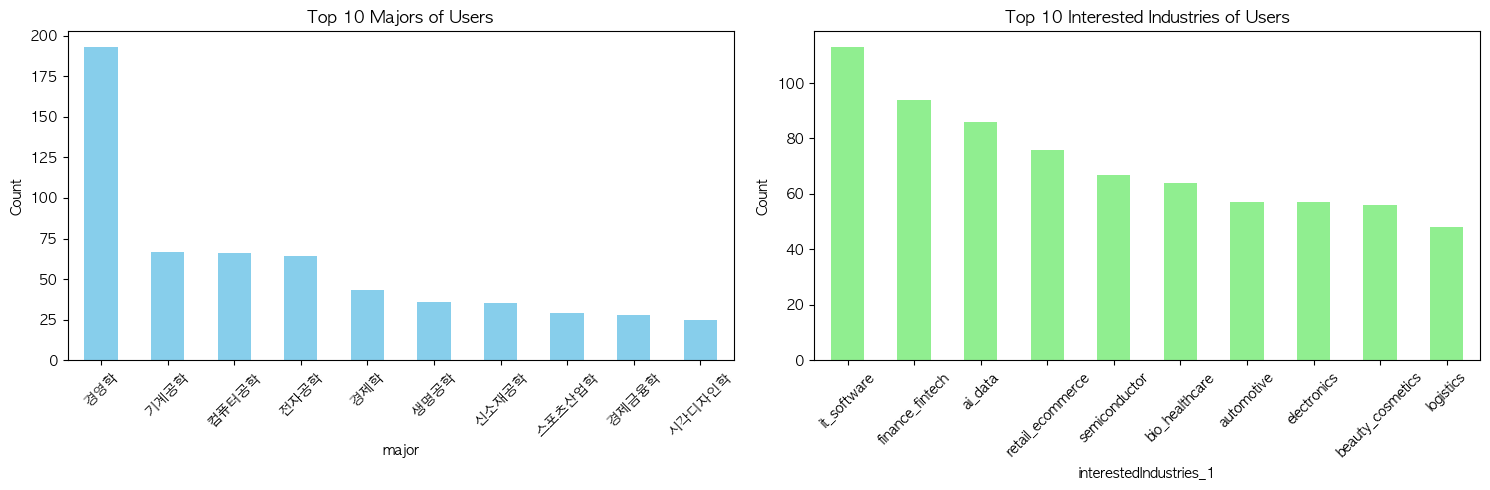

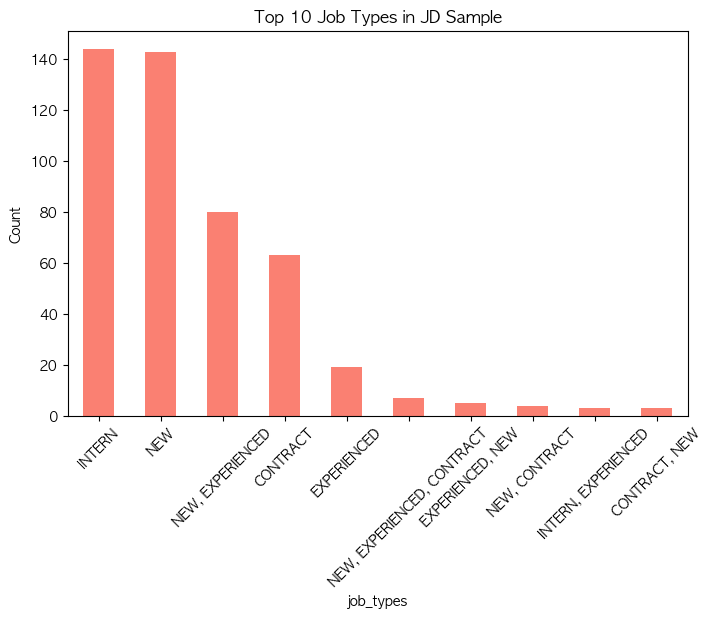

In [3]:
plt.figure(figsize=(15, 5))

# 유저 전공 분포
plt.subplot(1, 2, 1)
df_user_sample['major'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Majors of Users')
plt.ylabel('Count')
plt.xticks(rotation=45)

# 유저 희망 산업 분포
plt.subplot(1, 2, 2)
df_user_sample['interestedIndustries_1'].value_counts().head(10).plot(kind='bar', color='lightgreen')
plt.title('Top 10 Interested Industries of Users')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# JD 요구 직무(job_types) 분포 확인
plt.figure(figsize=(8, 5))
df_jd_sample['job_types'].value_counts().head(10).plot(kind='bar', color='salmon')
plt.title('Top 10 Job Types in JD Sample')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


## 3. 임베딩 (Embedding) 생성
KR-SBERT 모델을 사용하여 텍스트를 임베딩합니다.
- User Text: `draftContent` (자기소개서) + `ability_0_keyword` (추출된 역량 키워드)
- JD Text: `duties_clean` (주요 업무) + `detail_text_clean` (상세 요강)

In [4]:
# KR-SBERT 모델 로드
print("Loading KR-SBERT model...")
model = SentenceTransformer('snunlp/KR-SBERT-V40K-klueNLI-augSTS')

# User Text 구성
df_user_sample['full_text'] = df_user_sample['ability_0_keyword'] + " " + df_user_sample['draftContent']

# JD Text 구성
df_jd_sample['full_text'] = df_jd_sample['duties_clean'] + " " + df_jd_sample['detail_text_clean']

# 임베딩 생성 (약 1~2분 소요)
print("Generating Embeddings for Users...")
user_embeddings = model.encode(df_user_sample['full_text'].tolist(), show_progress_bar=True, normalize_embeddings=True)

print("Generating Embeddings for JDs...")
jd_embeddings = model.encode(df_jd_sample['full_text'].tolist(), show_progress_bar=True, normalize_embeddings=True)

print(f"User Embedding Shape: {user_embeddings.shape}")
print(f"JD Embedding Shape: {jd_embeddings.shape}")


Loading KR-SBERT model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/467M [00:00<?, ?B/s]

Generating Embeddings for Users...


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Generating Embeddings for JDs...


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

User Embedding Shape: (999, 768)
JD Embedding Shape: (1000, 768)


## 4. Faiss 인덱스 구축 및 Top-K 매칭
JD 벡터들을 Faiss 인덱스에 넣고, 유저 벡터를 쿼리로 사용하여 Top-5 매칭 기업을 찾습니다.
(normalize_embeddings=True를 주었으므로 Inner Product는 Cosine Similarity와 동일합니다)

In [5]:
# Faiss 인덱스 생성 (Inner Product)
d = jd_embeddings.shape[1]
index = faiss.IndexFlatIP(d)
index.add(jd_embeddings)

print(f"Faiss Index contains {index.ntotal} JDs.")

# Top-K 매칭 (K=5)
k = 5
distances, indices = index.search(user_embeddings, k)

# 매칭 결과 일부 확인
print("\n[Matching Example - First User]")
user_idx = 0
print(f"User ID: {df_user_sample.iloc[user_idx]['userId']}")
print(f"User Major: {df_user_sample.iloc[user_idx]['major']}")
print(f"User Keywords: {df_user_sample.iloc[user_idx]['ability_0_keyword']}")
print("\n--- Top 5 Matching JDs ---")
for i in range(k):
    match_idx = indices[user_idx][i]
    score = distances[user_idx][i]
    print(f"Rank {i+1}: {df_jd_sample.iloc[match_idx]['company_name']} / {df_jd_sample.iloc[match_idx]['title']} (Score: {score:.4f})")


Faiss Index contains 1000 JDs.

[Matching Example - First User]
User ID: P0462
User Major: 기계공학
User Keywords: 디지털·기술 활용 역량 실행력·업무처리 능력 학습·성장 역량 협업·팀워크

--- Top 5 Matching JDs ---
Rank 1: 현대제철 / [현대제철] 인사 사무보조 계약직 채용 (당진) (Score: 0.7012)
Rank 2: 하이퍼리즘 / [하이퍼리즘] 사업개발 인턴 채용 (경력/학력 무관, 정규직 전환 가능) (Score: 0.6796)
Rank 3: 교원그룹 / [교원그룹] 2023년 12월 교원웰스부문 경력 정기채용 (Score: 0.6760)
Rank 4: 업라이즈 / cx/운영 헤이비트(HEYBIT) CS/CX 인턴 (Score: 0.6734)
Rank 5: 현대자동차 / [현대자동차] [SDF] 제조 DX 솔루션 / 시스템 아키텍트 (Score: 0.6731)


## 5. 실제 쿼리 함수 (User -> JD 매칭)
특정 `userId`를 입력받아 실시간으로 추천 기업을 출력하는 함수입니다.

In [6]:
def query_matching(user_id, k=5):
    # 유저 정보 찾기
    user_row = df_user_agg[df_user_agg['userId'] == user_id]
    if len(user_row) == 0:
        return f"User {user_id} not found."
    
    # 임베딩
    text = user_row.iloc[0]['ability_0_keyword'] + " " + user_row.iloc[0]['draftContent']
    vec = model.encode([text], normalize_embeddings=True)
    
    # Faiss 검색
    D, I = index.search(vec, k)
    
    print(f"========== Matching Result for {user_id} ==========")
    print(f"[User Profile] Major: {user_row.iloc[0]['major']} | Keywords: {user_row.iloc[0]['ability_0_keyword']}")
    print("-" * 50)
    for i in range(k):
        match_idx = I[0][i]
        score = D[0][i]
        jd_info = df_jd_sample.iloc[match_idx]
        print(f"[{i+1}] {jd_info['company_name']} - {jd_info['title']} (Score: {score:.4f})")
        
# 테스트 실행 (데이터셋에 있는 임의의 유저 ID 사용)
sample_id = df_user_sample.iloc[42]['userId']
query_matching(sample_id)


========== Matching Result for P0950 ==========
[User Profile] Major: 보건환경융합과학 | Keywords: 정보수집·분석 역량 리더십·팔로워십 실행력·업무처리 능력
--------------------------------------------------
[1] 업라이즈 - cx/운영 헤이비트(HEYBIT) CS/CX 인턴 (Score: 0.7205)
[2] 카카오엔터프라이즈 - 2021년 정보보안 인증 인턴 채용 (Score: 0.7089)
[3] 그린코드 - AI x ESG 실전 프로젝트 동아리 [그린코드] 모집 (Score: 0.6965)
[4] 하이퍼리즘 - [하이퍼리즘] 사업개발 인턴 채용 (경력/학력 무관, 정규직 전환 가능) (Score: 0.6934)
[5] 미래에셋자산운용 - 미래에셋자산운용 [재무회계] 자금, 회계관리 Associate (Score: 0.6839)
